In [33]:
#bai23.1
import folium

# Tọa độ Nguyễn Tri Phương (UEH csB)
ueh_location= [10.761285072889024, 106.6683579950703]
m = folium.Map(location=ueh_location,zoom_start=16)
# tạo marker
folium.Marker(ueh_location,popup=" Đại học UEH ", tooltip="Click để xem",
icon=folium.Icon(color='red',icon='university',prefix='fa')).add_to(m)

#5 địa điểm công cộng
public_places =[
    {"name": "Bệnh viện 30/4 ","coord": [10.759758266094773, 106.67490160591802]},
    {"name": "Công viên Lê Thị Riêng  ","coord": [10.786012022953196, 106.66492036062307]},
    {"name": "Nhà hàng Gần Đây ","coord": [10.765090899144099, 106.66804830524066]},
    {"name": "Trạm xe buýt NTP ","coord": [10.761434510526863, 106.66863949537901]},
    {"name": "Chợ Nhật Tảo  ","coord": [10.76490646992333, 106.66793565274165]},]

for place in public_places:
   folium.Marker(place["coord"],popup=place["name"]).add_to(m)
m

In [35]:
#bai 23.2,
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
geolocator = Nominatim(user_agent="my_app")
center_point = [10.761285072889024,106.6683579950703]# địa chỉ ueh
m = folium.Map(location=center_point,zoom_start=15)
# danh sách địa chỉ
addreses = ["Đinh Độc Lập, TP.HCM ","Nhà thờ Đức Bà, TP.HCM","Chợ Bến Thành, TP.HCM","Bảo tàng lịch sử Việt Nam, TP.HCM",
            "Phố đi bộ Nguyễn Huệ, TP.HCM","Thảo Cầm Viên, TP.HCM","Bảo tàng tranh  3D Artinus, TP.HCM ",
            "Tòa nhà Bitexco, TP.HCM","Công viên nước Đầm Sen, TP.HCM","Nhà hát Hòa Bình,TP.HCM"]
for addr in addresses:
    location= geolocator.geocode(addr)
    if location:
        point = [location.latitude,location.longitude]
        dist = geodesic(center_point,point).km
        folium.Marker(point,popup=f"{addr}:{dist:.2f} km").add_to(m)
m



In [12]:
# bài tập 23.3
import folium
from folium.plugins import HeatMap
import numpy as np

# Giả lập 100 điểm dữ liệu đơn hàng/khách hàng
center = [10.7828, 106.6958]
data = (np.random.normal(size=(100, 2)) * 0.01 + center).tolist()

m3 = folium.Map(location=center, zoom_start=14)
HeatMap(data).add_to(m3)

print("Ý NGHĨA QUẢN TRỊ: Vùng màu đỏ thể hiện 'điểm nóng' nhu cầu. ")
print("Nhà quản trị nên điều phối thêm shipper hoặc đặt kho bãi tại đây để tối ưu chi phí vận hành.")
m3

Ý NGHĨA QUẢN TRỊ: Vùng màu đỏ thể hiện 'điểm nóng' nhu cầu. 
Nhà quản trị nên điều phối thêm shipper hoặc đặt kho bãi tại đây để tối ưu chi phí vận hành.


In [4]:
!pip install geopandas openpyxl matplotlib

         Tỉnh thành   Dân số   Doanh thu   Mức tiêu thụ
0   Thành phố Hà Nội  8459550     5806181            97
1      Tỉnh Hà Giang  1295562      636418            44
2      Tỉnh Cao Bằng   940256      835677            60
3       Tỉnh Bắc Kạn   744098      842975            48
4   Tỉnh Tuyên Quang   780293      475195            57
..               ...      ...         ...           ...
58    Tỉnh Hậu Giang  1485261      826537            37
59    Tỉnh Sóc Trăng   955524      641055            30
60     Tỉnh Bạc Liêu  1234125      963797            34
61       Tỉnh Cà Mau   843210     1229969            64
62    Tỉnh Vĩnh Phúc   876883     1294844            57

[63 rows x 4 columns]


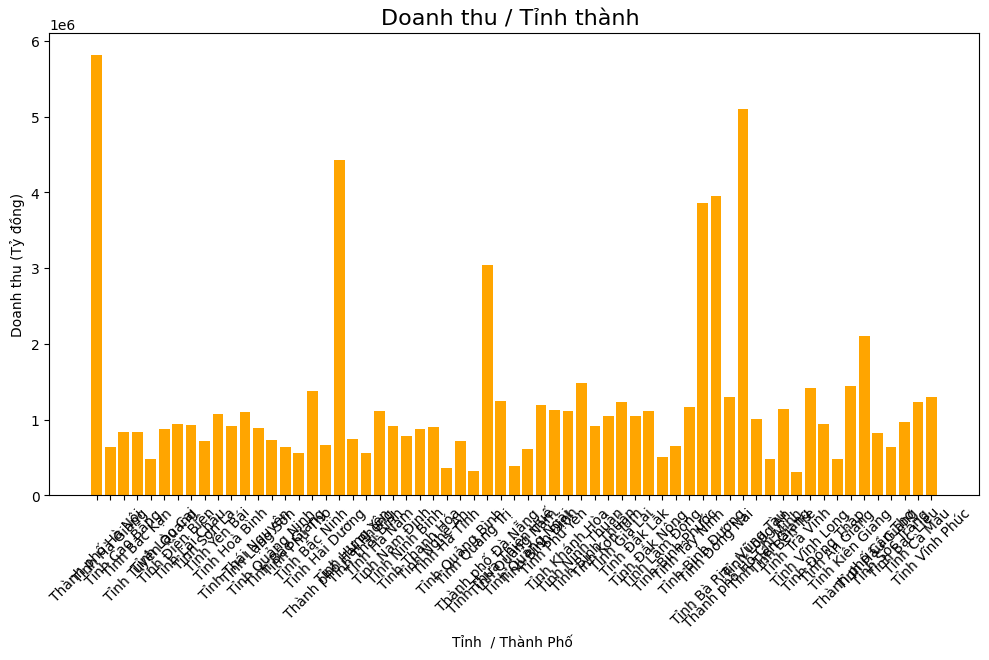

Nhận xét:
- Doanh thu giữa các tỉnh thành  có sự khác biệt rõ rệt.
- Một số khu vực trung tâm có doanh thu cao hơn.
- Các khu vực thấp hơn cần tăng đầu tư và phát triển.


In [13]:
#bai 24.4

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_excel("/content/Du_Lieu_Quan_Tri_63_Tinh_Thanh.xlsx")


print(df)


plt.figure(figsize=(12,6))
plt.bar(df["Tỉnh thành "], df["Doanh thu "], color="orange")

plt.title("Doanh thu / Tỉnh thành ", fontsize=16)
plt.xlabel("Tỉnh  / Thành Phố ")
plt.ylabel("Doanh thu (Tỷ đồng)")
plt.xticks(rotation=45)
plt.show()

# Nhận xét
print("Nhận xét:")
print("- Doanh thu giữa các tỉnh thành  có sự khác biệt rõ rệt.")
print("- Một số khu vực trung tâm có doanh thu cao hơn.")
print("- Các khu vực thấp hơn cần tăng đầu tư và phát triển.")

In [14]:
#bài 23.5
import folium

center = [10.782052444819872, 106.62037135464881] # Kho hàng quận 1
m5 = folium.Map(location=center, zoom_start=12)

configs = [(3000, 'green', 'Vùng ưu tiên (Giao nhanh)'),
           (5000, 'orange', 'Vùng tiêu chuẩn'),
           (10000, 'red', 'Vùng xa (Phụ phí)')]

for radius, color, note in configs:
    folium.Circle(location=center, radius=radius, color=color, fill=True, fill_opacity=0.1, popup=note).add_to(m5)

print("ĐÁNH GIÁ: Vùng xanh là khu vực tối ưu cho cam kết giao hàng dưới 30 phút.")
m5

ĐÁNH GIÁ: Vùng xanh là khu vực tối ưu cho cam kết giao hàng dưới 30 phút.


In [15]:
#bài 23.8
import folium
import numpy as np
from geopy.distance import geodesic

# vị trí khách hàng
customer_loc = [10.7600, 106.6660] # UEH Nguyễn Tri Phương
m8 = folium.Map(location=customer_loc, zoom_start=15)

#  5 xe taxi (random)
np.random.seed(42)
taxis_locs = (np.random.normal(size=(5, 2)) * 0.005 + customer_loc).tolist()

# Heuristic: (geodesic)
distances = [geodesic(customer_loc, taxi).meters for taxi in taxis_locs]
best_taxi_idx = np.argmin(distances)
best_taxi_loc = taxis_locs[best_taxi_idx]

#Trực quan hóa lên bản đồ
# Marker cho Khách hàng
folium.Marker(
    customer_loc,
    popup="Khách hàng (Cần xe)",
    icon=folium.Icon(color='red', icon='user', prefix='fa')
).add_to(m8)

# Marker cho các Xe
for i, loc in enumerate(taxis_locs):
    if i == best_taxi_idx:
        # Xe được chọn
        folium.Marker(
            loc,
            popup=f"Xe tối ưu (Cách {distances[i]:.1f}m)",
            icon=folium.Icon(color='green', icon='car', prefix='fa')
        ).add_to(m8)
        # Vẽ đường nối
        folium.PolyLine([customer_loc, loc], color="green", weight=3, dash_array='10').add_to(m8)
    else:
        # Các xe khác
        folium.Marker(
            loc,
            popup=f"Xe trống (Cách {distances[i]:.1f}m)",
            icon=folium.Icon(color='blue', icon='car', prefix='fa')
        ).add_to(m8)

# Hiển thị
print(f"Hệ thống đã ghép khách hàng với xe số {best_taxi_idx + 1}")
print(f"Khoảng cách đường chim bay: {distances[best_taxi_idx]:.2f} mét")
m8

Hệ thống đã ghép khách hàng với xe số 3
Khoảng cách đường chim bay: 182.12 mét


In [17]:
#bài 23.10
import folium

m10 = folium.Map(location=[10.78, 106.69], zoom_start=15)
# Giả lập
roads = [
    {"coords": [[10.782, 106.695], [10.785, 106.698]], "risk": "High"},
    {"coords": [[10.780, 106.690], [10.782, 106.695]], "risk": "Low"}
]

for r in roads:
    color = 'red' if r["risk"] == "High" else 'green'
    folium.PolyLine(r["coords"], color=color, weight=7, tooltip=f"Nguy cơ: {r['risk']}").add_to(m10)

m10

In [19]:
23.6
import folium
from geopy.geocoders import Nominatim
import osmnx as ox
import networkx as nx
ktx = "43 - 45 Nguyen Chi Thanh, Ho Chi Minh City"
geolocator = Nominatim(user_agent = "geoapi", timeout = 100)
td = geolocator.geocode(ktx)
td_ktx = (td.latitude,td.longitude)
m = folium.Map(location = td_ktx, zoom_start = 13)
folium.Marker(location = td_ktx, popup = "KTX").add_to(m)

ox.settings.timeout = 300
G = ox.graph_from_point(td_ktx, dist = 100, network_type = "walk")
stats = ox.basic_stats(G)
print(f"Số nút giao: {stats['n']}")
print(f"Số đoạn đường: {stats['m']}")
print(f"Chiều dài trung bình: {stats['street_length_avg']:.2f}m")
nodes, edges = ox.graph_to_gdfs(G)
folium.GeoJson(edges).add_to(m)
m

Số nút giao: 24
Số đoạn đường: 46
Chiều dài trung bình: 33.50m


In [2]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.6 MB/s eta 0:00:00
